# Day 02 — Pictogram
### #30DayChartChallenge | April 2026

**For every 10 people, how many smoke?** In Indonesia 6 in 10 men smoke, but almost no women do. In France the gap barely exists. A pictogram showing smoking prevalence by gender across 8 countries.

**Data:**  
WHO age-standardized estimates via [World Population Review](https://worldpopulationreview.com/country-rankings/smoking-rates-by-country), 2025.

**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------
# install.packages("ggpop")   # run once if not installed

library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(ggpop)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'showtext' was built under R version 4.5.3"
Loading required package: sysfonts

Warning message:
"package 'sysfonts' was built under R version 4.5.3"
Loading required package: showtextdb

Warning message:
"package 'showtextdb' was built under R version 4.5.3"
Warning message:
"package 'ggpop' was built under R version 4.5.3"


In [2]:
# — fonts ---------------------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

# set notebook preview to match ggsave dimensions
options(repr.plot.width = 14, repr.plot.height = 18, repr.plot.res = 300)

In [3]:
# — read data -----------------------------------------------------------------

sm <- read.csv("../../data/day_02/who_2024_smoking_prevalence_by_gender.csv",
               stringsAsFactors = FALSE)

# sort descending by male rate
sm <- sm[order(-sm$male_pct), ]

sm

,country,male_pct,female_pct,male_per_10,female_per_10
,<chr>,<dbl>,<dbl>,<int>,<int>
1,Indonesia,59.3,1.1,6,0
2,China,44.0,1.3,4,0
3,Turkey,39.3,19.6,4,2
4,France,31.7,28.5,3,3
5,Germany,17.8,15.7,2,2
6,United States,11.2,7.9,1,1
7,Australia,9.0,6.5,1,1
8,India,7.3,0.4,1,0


In [4]:
# — expand: 10 male + 10 female icons per country ----------------------------

x_gap       <- 2.5   # space between icons horizontally
y_gap_inner <- 2.2   # male <-> female gap within a country
y_gap_outer <- 5.5   # gap between countries

n <- nrow(sm)
sm$y_base <- rev(seq(0, by = y_gap_outer, length.out = n))

icons_df <- do.call(rbind, lapply(seq_len(n), function(i) {
  yb <- sm$y_base[i]

  male_row <- data.frame(
    country    = sm$country[i],
    gender     = "male",
    x          = seq_len(10) * x_gap,
    y          = yb + y_gap_inner,
    icon       = "male",
    is_smoker  = seq_len(10) <= sm$male_per_10[i]
  )

  female_row <- data.frame(
    country    = sm$country[i],
    gender     = "female",
    x          = seq_len(10) * x_gap,
    y          = yb,
    icon       = "female",
    is_smoker  = seq_len(10) <= sm$female_per_10[i]
  )

  rbind(male_row, female_row)
}))

# 4 color groups: one icon per group (fixes legend warning)
icons_df$color_group <- ifelse(
  icons_df$is_smoker & icons_df$gender == "male", "Male smoker",
  ifelse(icons_df$is_smoker & icons_df$gender == "female", "Female smoker",
    ifelse(!icons_df$is_smoker & icons_df$gender == "male", "Male non-smoker",
      "Female non-smoker"
    )
  )
)
icons_df$color_group <- factor(
  icons_df$color_group,
  levels = c("Male smoker", "Female smoker", "Male non-smoker", "Female non-smoker")
)

cat(nrow(icons_df), "icons total\n")

160 icons total


In [5]:
# — labels --------------------------------------------------------------------

bg      <- "#0D1117"
txt     <- "#E6EDF3"
txt_dim <- "#8B949E"
txt_cap <- "#484F58"

# country name (centered between the two rows)
country_labs <- data.frame(
  x     = x_gap * 0.25,
  y     = sm$y_base + y_gap_inner / 2,
  label = sm$country
)

# male percentage (right of male row)
male_labs <- data.frame(
  x     = 11.2 * x_gap,
  y     = sm$y_base + y_gap_inner,
  label = paste0(sm$male_pct, "%")
)

# female percentage (right of female row)
female_labs <- data.frame(
  x     = 11.2 * x_gap,
  y     = sm$y_base,
  label = paste0(sm$female_pct, "%")
)

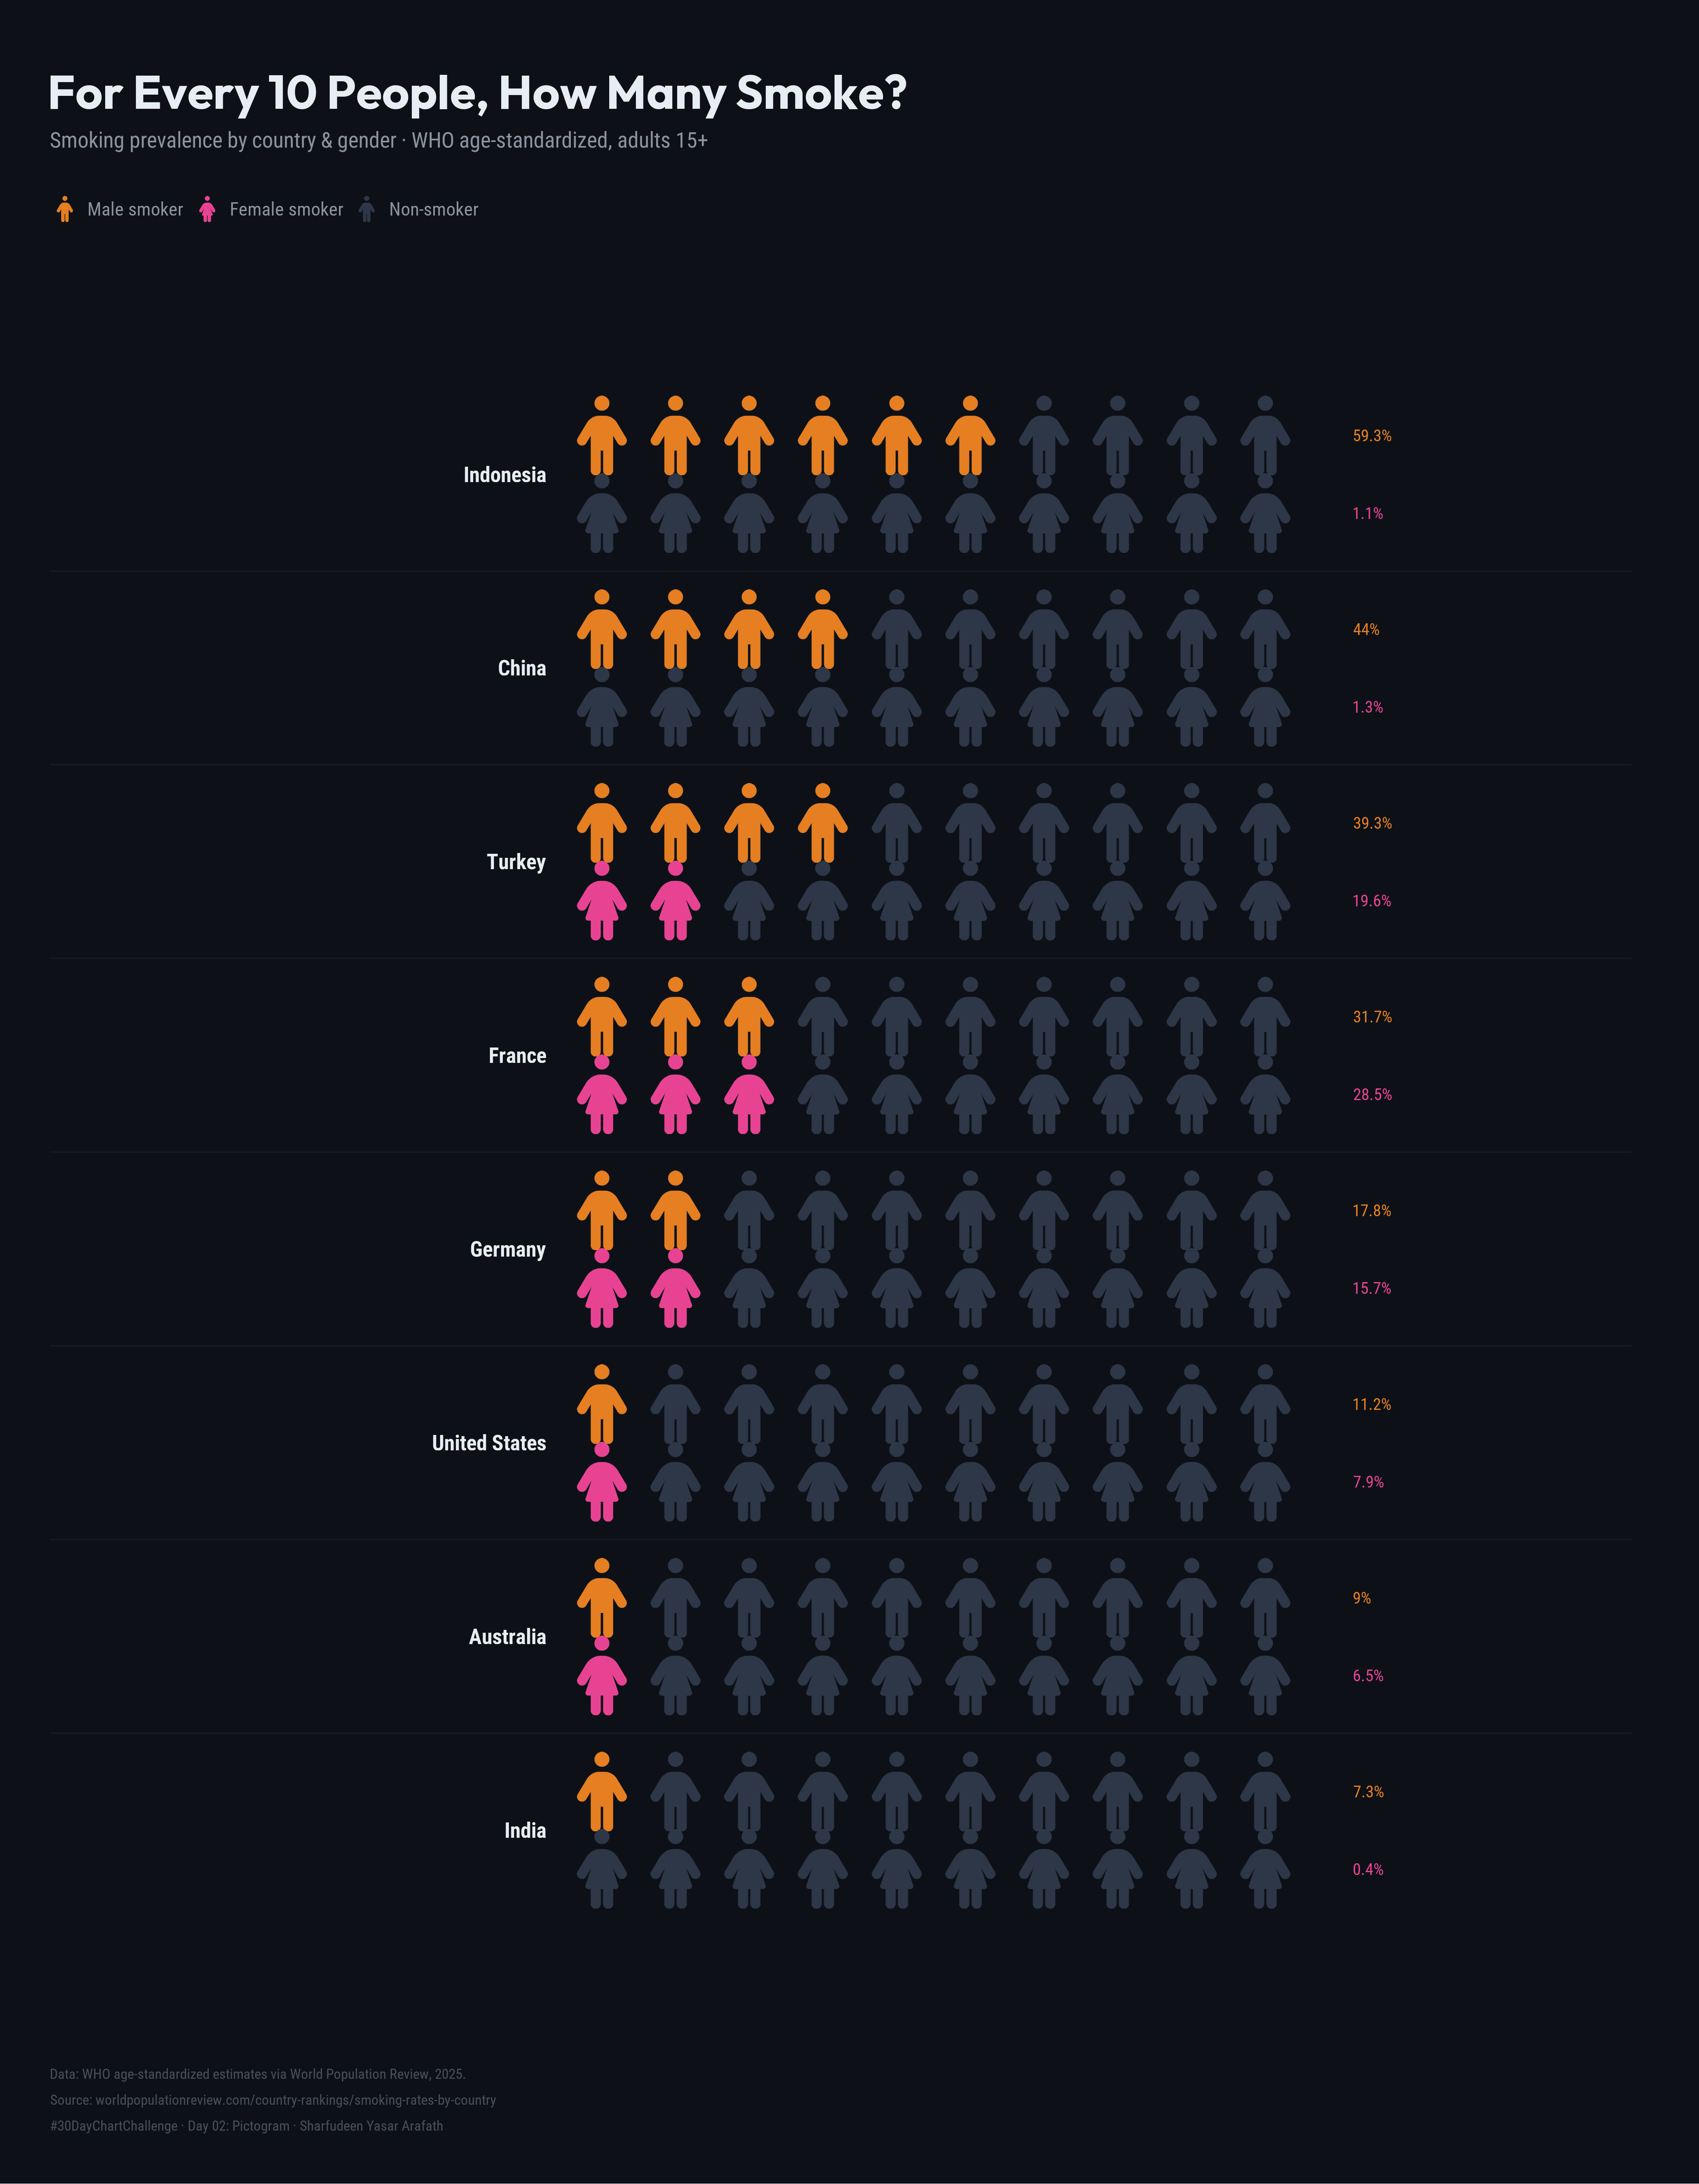

In [6]:
# — plot ----------------------------------------------------------------------

p <- ggplot(icons_df, aes(x = x, y = y, icon = icon, color = color_group)) +

  # subtle separator lines between countries
  geom_hline(
    yintercept = sm$y_base[-1] + (y_gap_outer - y_gap_inner) / 2 + y_gap_inner,
    color = "#161B22", linewidth = 0.4
  ) +

  # icons
  geom_icon_point(size = 1.5, dpi = 300) +

  scale_color_manual(
    values = c(
      "Male smoker"      = "#E67E22",
      "Female smoker"    = "#E84393",
      "Male non-smoker"  = "#2D3748",
      "Female non-smoker"= "#2D3748"
    ),
    breaks = c("Male smoker", "Female smoker", "Male non-smoker"),
    labels = c("Male smoker", "Female smoker", "Non-smoker"),
    name = NULL
  ) +

  # country names (left)
  geom_text(data = country_labs,
            aes(x = x, y = y, label = label),
            inherit.aes = FALSE,
            hjust = 1, color = txt, family = "roboto_condensed",
            fontface = "bold", size = 4.5) +

  # male % (right)
  geom_text(data = male_labs,
            aes(x = x, y = y, label = label),
            inherit.aes = FALSE,
            hjust = 0, color = "#E67E22", family = "roboto_condensed",
            size = 3.5) +

  # female % (right)
  geom_text(data = female_labs,
            aes(x = x, y = y, label = label),
            inherit.aes = FALSE,
            hjust = 0, color = "#E84393", family = "roboto_condensed",
            size = 3.5) +

  scale_x_continuous(limits = c(-5.5 * x_gap, 14 * x_gap)) +
  scale_y_continuous(
    limits = c(-y_gap_outer * 0.4,
               max(sm$y_base) + y_gap_inner + y_gap_outer * 0.5)
  ) +
  coord_cartesian(clip = "off") +

  labs(
    title    = "For Every 10 People, How Many Smoke?",
    subtitle = paste0(
      "Smoking prevalence by country & gender \u00b7 ",
      "WHO age-standardized, adults 15+"
    ),
    caption  = paste0(
      "Data: WHO age-standardized estimates via World Population Review, 2025.\n",
      "Source: worldpopulationreview.com/country-rankings/",
      "smoking-rates-by-country\n",
      "#30DayChartChallenge \u00b7 Day 02: Pictogram \u00b7 ",
      "Sharfudeen Yasar Arafath"
    )
  ) +

  theme_void(base_family = "roboto_condensed") +
  theme(
    plot.title       = element_text(family = "outfit", face = "bold", size = 28,
                                    hjust = 0, color = txt,
                                    margin = margin(t = 20, b = 8)),
    plot.subtitle    = element_text(size = 13, hjust = 0, color = txt_dim,
                                    margin = margin(b = 25)),
    plot.caption     = element_text(size = 8.5, hjust = 0, color = txt_cap,
                                    margin = margin(t = 25, b = 10),
                                    lineheight = 1.5),
    legend.position  = "top",
    legend.justification = "left",
    legend.text      = element_text(size = 11, color = txt_dim),
    legend.margin    = margin(b = 15),
    plot.background  = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin      = margin(25, 40, 20, 30)
  ) +
  guides(color = guide_legend(
    override.aes = list(size = 4)
  ))

p

In [7]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_02_pictogram.png",
       plot = p, width = 14, height = 18, dpi = 300, bg = bg)

cat("Done — saved to chart/day_02_pictogram.png\n")

Done — saved to chart/day_02_pictogram.png
